In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Preliminary Analysis

In [42]:
prefix = "D:/IITK Certification/Capstone/Capstone 2/Part 2"
tourism_with_id = pd.read_excel(prefix + "/tourism_with_id.xlsx")
tourism_rating = pd.read_csv(prefix + "/tourism_rating.csv")
user = pd.read_csv(prefix + "/user.csv")

In [43]:
tourism_with_id.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5


In [44]:
tourism_rating.head()

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4


In [45]:
user.head()

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23
3,4,"Bekasi, Jawa Barat",21
4,5,"Lampung, Sumatera Selatan",20


In [46]:
tourism_with_id.drop(columns = ['Unnamed: 11', 'Unnamed: 12'], inplace = True)

In [47]:
### Check null in each dataset
datasets = {
    "tourism_with_id": tourism_with_id,
    "tourism_rating": tourism_rating,
    "user": user
}

for name, df in datasets.items():
    print(f"Dataset: {name}")
    print(df.isnull().sum())
    print("\n\n")


Dataset: tourism_with_id
Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
dtype: int64



Dataset: tourism_rating
User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64



Dataset: user
User_Id     0
Location    0
Age         0
dtype: int64





In [48]:
### Only Time Minutes field in tourism_with_id dataset has null values.

In [49]:
### Remove duplicates in all 3 datasets
for name, df in datasets.items():
    print(f"Dataset: {name}")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
    print("\n\n")

Dataset: tourism_with_id
Number of duplicate rows: 0



Dataset: tourism_rating
Number of duplicate rows: 79



Dataset: user
Number of duplicate rows: 0





In [ ]:
### 79 duplicate rows in tourism_rating dataset.

### Exploratory Data Analysis (EDA)

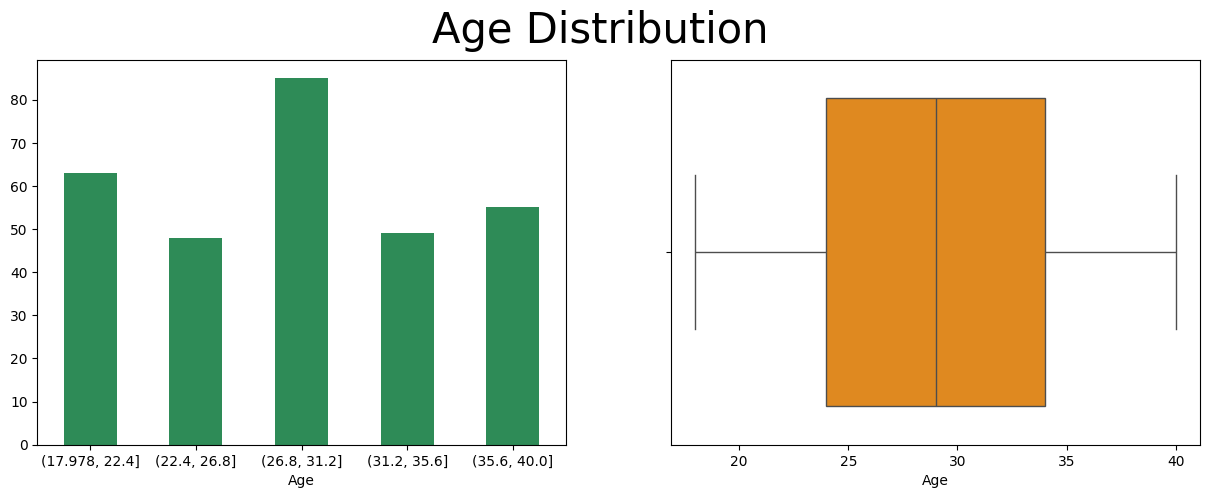

In [51]:
# Analyzing the age distribution of users visiting the places and rating them
f, ax = plt.subplots(1,2, figsize = (15,5))
age_groups = pd.cut(user.Age, bins = 5, )
vc = age_groups.value_counts()
vc = vc.sort_index()
vc.plot.bar(ax = ax[0],color = 'seagreen')
sns.boxplot(x = user.Age, ax = ax[1], color = 'darkorange')
ax[0].set_xticklabels(labels = vc.index, rotation = 0, )
plt.suptitle("Age Distribution", size = 30)
plt.show()

In [52]:
# Most of the users are in the age group of 26 - 31years. 
# The distribution quite normal with most of the users concentrated around the mean age of 30 years.

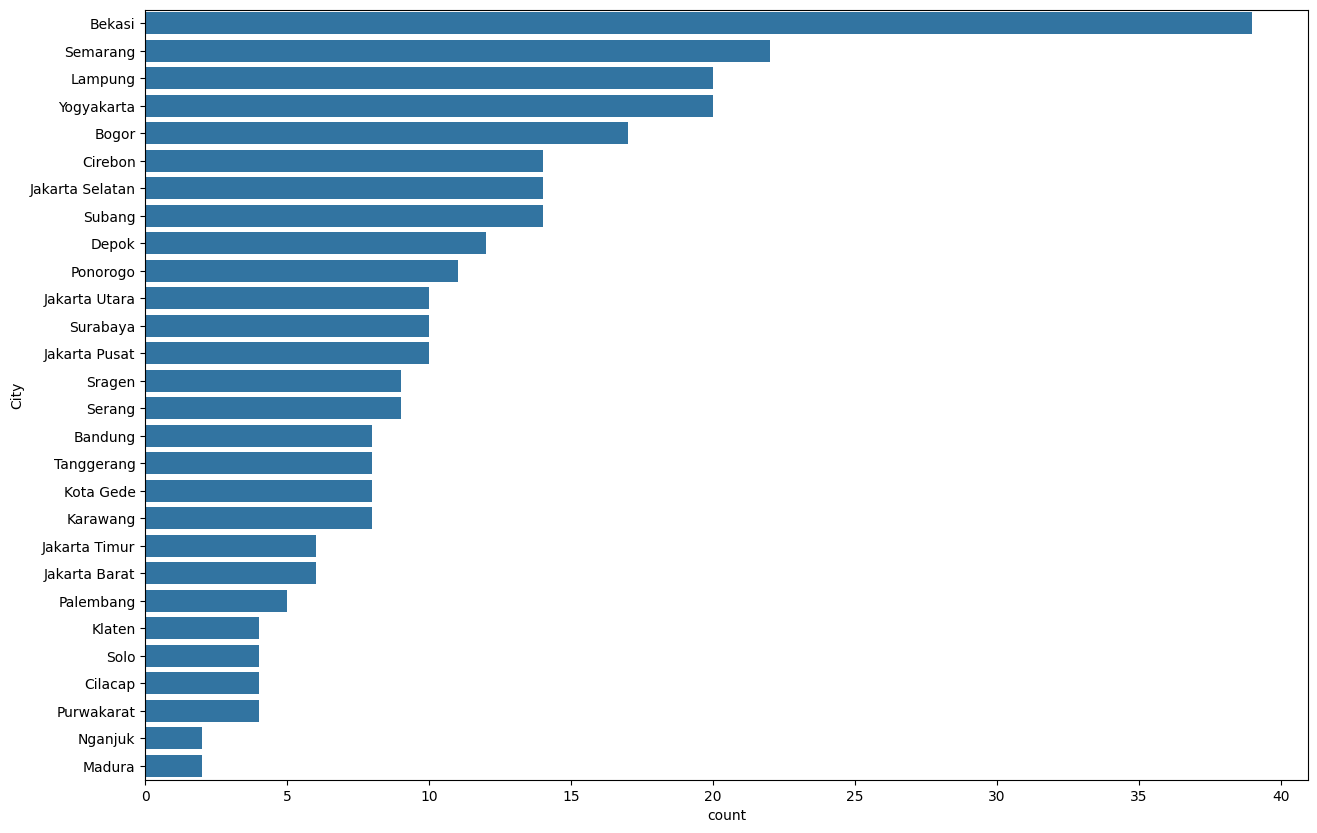

In [53]:
# Identifying the places where most of these users (tourists) are coming from
user['City'] = user['Location'].apply(lambda x: x.split(',')[0].strip())

vc = user.City.value_counts()
plt.figure(figsize = (15,10))
sns.countplot(y = "City", data = user, order = vc.index)
plt.show()

In [54]:
# Top 3 cities of users are Bekasi, Semarang and Lampung.

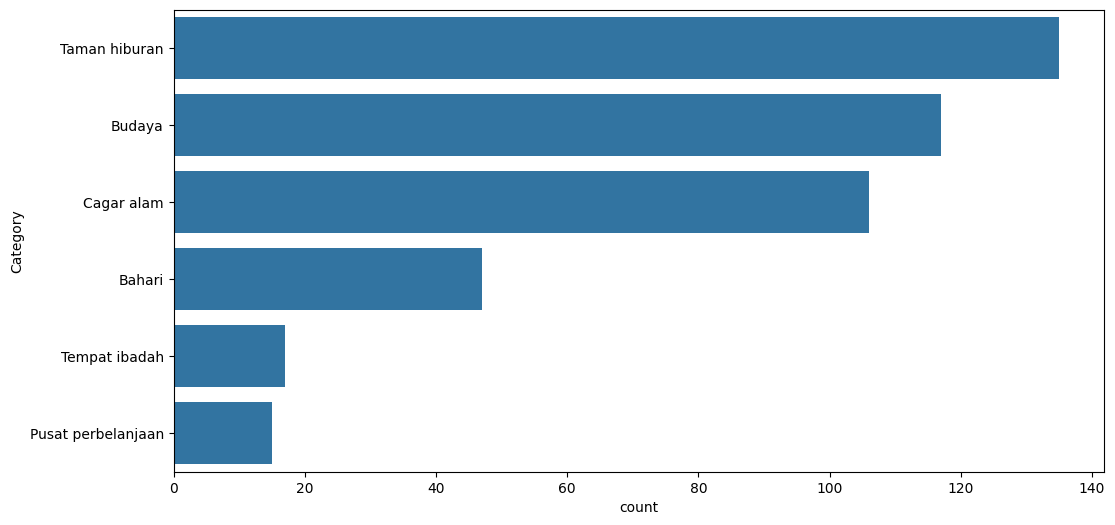

In [55]:
# Different categories of tourist spots
tourism_with_id['Category'] = tourism_with_id['Category'].str.strip().str.capitalize()
plt.figure(figsize = (12,6))
sns.countplot(y = "Category", data = tourism_with_id, order = tourism_with_id.Category.value_counts().index)
plt.show()

In [56]:
# Top 3 categories of tourist spots are Taman hiburan, Budaya, Cagar alam.

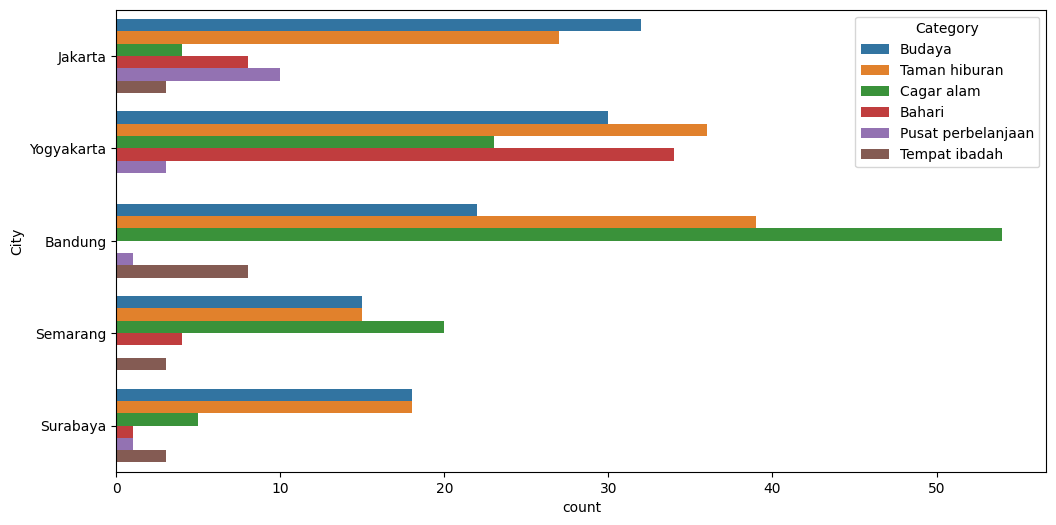

In [57]:
# Top Tourism category in each city
tourism_with_id['City'] = tourism_with_id['City'].str.strip().str.capitalize()
plt.figure(figsize = (12,6))
sns.countplot(y = "City", hue = "Category", data = tourism_with_id)
plt.show()

In [58]:
# Top Tourism category in each city:
# Jakarta: Budaya
# Yogyakarta: Taman hiburan
# Bandung: Cagar alam
# Semarang: Cagar alam
# Surabaya: Budaya

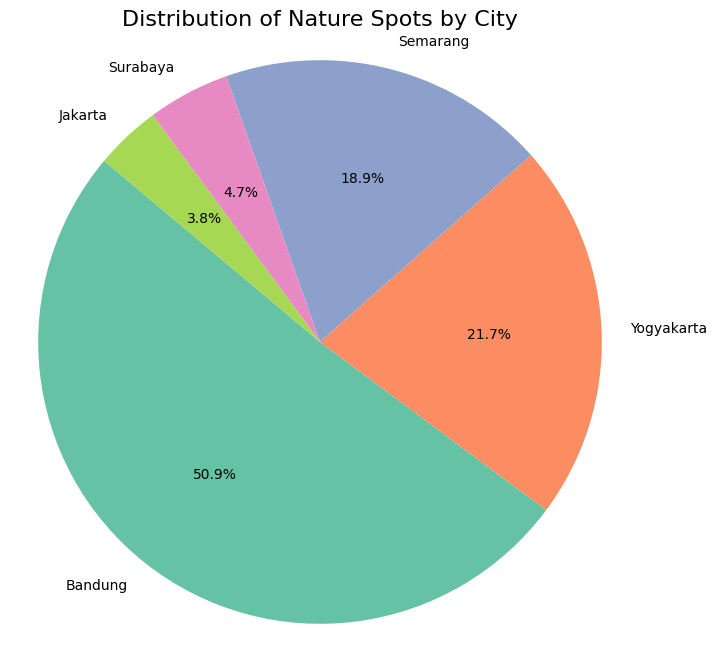

In [59]:
# Best city for nature enthusiasts

# According to the above plot, Bandung is the best city for nature enthusiasts as they have the highest number of tourist spots categorized as "Cagar alam" (nature reserves).
# pie chart
nature_spots = tourism_with_id[tourism_with_id['Category'] == 'Cagar alam']
nature_spots_city_counts = nature_spots['City'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(nature_spots_city_counts, labels=nature_spots_city_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Distribution of Nature Spots by City', size=16)
plt.axis('equal')
plt.show()

In [ ]:
# Use this data to figure out the spots that are most loved by the tourists.
# Indonesia provides a wide range of tourist spots ranging from historical and cultural beauties to advanced amusement parks. 
# Among these, which category of places are users liking the most?

ratings = tourism_rating.groupby('Place_Id')[['Place_Ratings']].mean().round(2).reset_index()
ratings.head(5)

,Place_Id,Place_Ratings
0,1,3.72
1,2,2.84
2,3,2.53
3,4,2.86
4,5,3.52


In [61]:
place_ratings = pd.merge(tourism_with_id,ratings, on = 'Place_Id', how = "left")
place_ratings.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Place_Ratings
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,3.72
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,2.84
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,2.53
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,2.86
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,3.52


In [62]:
place_ratings.sort_values("Place_Ratings",ascending = False)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Place_Ratings
415,416,Keraton Surabaya,Kawasan yang berjuluk Kampung Keraton ini terd...,Budaya,Surabaya,0,4.4,NaN,"{'lat': -7.256755299999998, 'lng': 112.7942203}",-7.256755,112.794220,3.97
138,139,Puncak Gunung Api Purba - Nglanggeran,Gunung Nglanggeran adalah sebuah gunung di Dae...,Cagar alam,Yogyakarta,10000,4.7,60.0,"{'lat': -7.841252999999998, 'lng': 110.543056}",-7.841253,110.543056,3.88
51,52,Kampung Cina,KAMPUNG China adalah hunian dan kawasan perdag...,Budaya,Jakarta,15000,4.5,NaN,"{'lat': -6.3651357, 'lng': 106.7617984}",-6.365136,106.761798,3.84
253,254,Teras Cikapundung BBWS,Teras Cikapundung Bandung sebelumnya merupakan...,Taman hiburan,Bandung,0,4.3,60.0,"{'lat': -6.8844199, 'lng': 107.6068344}",-6.884420,107.606834,3.79
321,322,Bukit Jamur,Bukit Jamur Ciwidey adalah satu dari sekian ba...,Cagar alam,Bandung,0,4.2,NaN,"{'lat': -7.195110199999998, 'lng': 107.4312811}",-7.195110,107.431281,3.77
...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,Museum Perangko,Museum perangko dibangun dengan bentuk banguna...,Budaya,Jakarta,5000,4.4,NaN,"{'lat': -6.304184100000001, 'lng': 106.9017725}",-6.304184,106.901773,2.24
233,234,Amazing Art World,"Amazing Art World Bandung, sebuah objek wisata...",Budaya,Bandung,75000,4.5,45.0,"{'lat': -6.8516591, 'lng': 107.5955534}",-6.851659,107.595553,2.22
208,209,Pantai Sanglen,Pantai Sanglen. Lokasinya berada di Desa Kemad...,Bahari,Yogyakarta,10000,4.5,NaN,"{'lat': -8.1367456, 'lng': 110.5716362}",-8.136746,110.571636,2.21
103,104,Tebing Breksi,Tebing Breksi merupakan tempat wisata yang ber...,Budaya,Yogyakarta,20000,4.4,NaN,"{'lat': -7.781571400000001, 'lng': 110.5045827}",-7.781571,110.504583,2.17


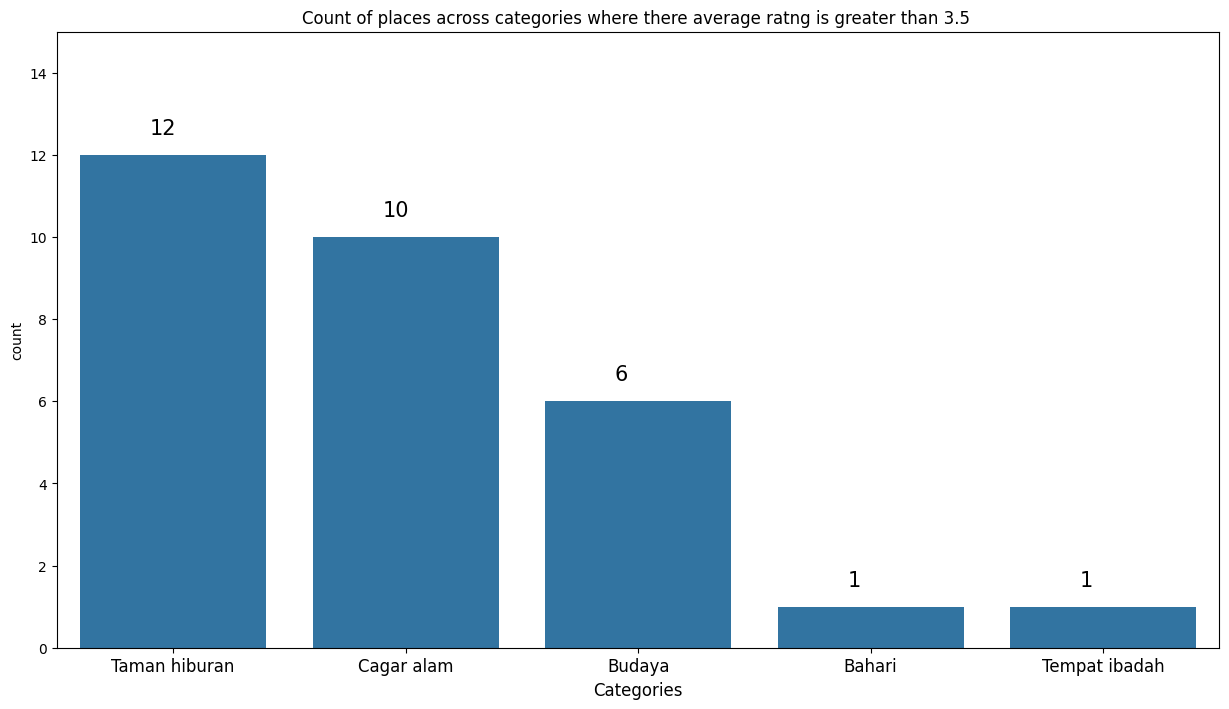

In [65]:
# Taking 3.5 as the threshold to find popular tourist spots across categories.
vc = place_ratings[place_ratings.Place_Ratings >3.5].Category.value_counts()
plt.figure(figsize = (15,8))
sns.countplot(x = "Category", data = place_ratings[place_ratings.Place_Ratings >3.5], order = vc.index)
i= 0
for idx in vc.index:
  plt.annotate(vc[idx], xy = (i-0.1, vc[idx]+0.5), size = 15)
  i += 1
plt.xlabel('Categories', size = 12)
plt.ylim(0, 15)
plt.xticks(size = 12)
plt.title("Count of places across categories where there average ratng is greater than 3.5 ")
plt.show()
plt.show()

In [66]:
# Taman hiburan category has the most loved tourist spots with 12 places having a rating of more than 3.5.

In [69]:
# Also, which city has the most loved tourist spots.
place_ratings_city = place_ratings.groupby('City')[['Place_Ratings']].mean().round(2).reset_index()
place_ratings_city.sort_values("Place_Ratings", ascending = False)

,City,Place_Ratings
4,Yogyakarta,3.10
0,Bandung,3.08
3,Surabaya,3.06
2,Semarang,3.04
1,Jakarta,3.02


In [ ]:
# Yogyakarta has the highest average place ratings.

### Recommendation Model

In [72]:
# Buld a recommendation system to recommend tourist spots to users based on their ratings and the ratings of other users

In [68]:
recom_data = tourism_rating.merge(tourism_with_id[["Place_Id", "Place_Name", "City"]], on = "Place_Id", how = "left")
recom_data.head(5)

,User_Id,Place_Id,Place_Ratings,Place_Name,City
0,1,179,3,Candi Ratu Boko,Yogyakarta
1,1,344,2,Pantai Marina,Semarang
2,1,5,5,Atlantis Water Adventure,Jakarta
3,1,373,3,Museum Kereta Ambarawa,Semarang
4,1,101,4,Kampung Wisata Sosro Menduran,Yogyakarta


In [76]:
recom_data[recom_data['User_Id']==1]

,User_Id,Place_Id,Place_Ratings,Place_Name,City
0,1,179,3,Candi Ratu Boko,Yogyakarta
1,1,344,2,Pantai Marina,Semarang
2,1,5,5,Atlantis Water Adventure,Jakarta
3,1,373,3,Museum Kereta Ambarawa,Semarang
4,1,101,4,Kampung Wisata Sosro Menduran,Yogyakarta
5,1,312,2,Taman Hutan Raya Ir. H. Juanda,Bandung
6,1,258,5,Museum Gedung Sate,Bandung
7,1,20,4,Museum Taman Prasasti,Jakarta
8,1,154,2,Pantai Ngrawe (Mesra),Yogyakarta
9,1,393,5,Taman Harmoni Keputih,Surabaya


In [79]:
# Finding userwise and placewise ratings and normalizing it
ratings_data = recom_data.groupby(['User_Id', 'Place_Name'])['Place_Ratings'].mean().unstack()
data_norm = ratings_data.subtract(ratings_data.mean(axis=1), axis = 'rows')
data_norm.head()

Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
User_Id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.166667,NaN,NaN,NaN,NaN,-1.166667,NaN,-0.166667
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.344828,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
# Similarity
from sklearn.metrics.pairwise import cosine_similarity
user_similarity_cosine = cosine_similarity(data_norm.fillna(0))
user_similarity_cosine


array([[ 1.        ,  0.03595249,  0.05315137, ..., -0.03342215,
        -0.07420851, -0.01770365],
       [ 0.03595249,  1.        , -0.04806466, ..., -0.01931211,
         0.08701855,  0.03947492],
       [ 0.05315137, -0.04806466,  1.        , ..., -0.02313585,
         0.01083189, -0.05956819],
       ...,
       [-0.03342215, -0.01931211, -0.02313585, ...,  1.        ,
         0.01781543,  0.01973164],
       [-0.07420851,  0.08701855,  0.01083189, ...,  0.01781543,
         1.        , -0.06031953],
       [-0.01770365,  0.03947492, -0.05956819, ...,  0.01973164,
        -0.06031953,  1.        ]], shape=(300, 300))

In [86]:
# User similarity matrix using Pearson correlation
user_similarity = data_norm.T.corr()
user_similarity.head()

User_Id,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
User_Id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,NaN,NaN,0.981981,NaN,NaN,NaN,1.000000,-1.000000,0.188982,...,NaN,NaN,NaN,-0.192450,NaN,NaN,NaN,-1.000000,-0.379980,NaN
2,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,-1.0,-0.188982,NaN,-1.000000,-1.0,-0.5,-0.164771,-1.000000,0.577350,NaN
3,NaN,-1.0,1.0,NaN,NaN,NaN,NaN,1.000000,-0.654654,NaN,...,NaN,1.000000,NaN,-0.388889,-1.0,NaN,1.000000,1.000000,NaN,NaN
4,0.981981,NaN,NaN,1.000000,NaN,-9.819805e-01,0.333333,1.000000,-1.000000,NaN,...,-1.0,-1.000000,NaN,-1.000000,-1.0,1.0,-1.000000,NaN,0.944911,NaN
5,NaN,NaN,NaN,NaN,1.0,-5.551115e-17,NaN,0.191741,-1.000000,1.000000,...,1.0,NaN,-1.0,-0.320750,-1.0,NaN,NaN,0.760726,NaN,-1.0


In [87]:
# Pick a user ID
picked_userid = 1
# Remove picked user ID from the candidate list
user_similarity.drop(index=picked_userid, inplace=True)
# Take a look at the data
user_similarity.head()

User_Id,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
User_Id,,,,,,,,,,,,,,,,,,,,,
2,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,-1.0,-0.188982,NaN,-1.000000,-1.0,-0.5,-0.164771,-1.000000,0.577350,NaN
3,NaN,-1.0,1.0,NaN,NaN,NaN,NaN,1.000000,-0.654654,NaN,...,NaN,1.000000,NaN,-0.388889,-1.0,NaN,1.000000,1.000000,NaN,NaN
4,0.981981,NaN,NaN,1.000000,NaN,-9.819805e-01,0.333333,1.000000,-1.000000,NaN,...,-1.0,-1.000000,NaN,-1.000000,-1.0,1.0,-1.000000,NaN,0.944911,NaN
5,NaN,NaN,NaN,NaN,1.000000e+00,-5.551115e-17,NaN,0.191741,-1.000000,1.0,...,1.0,NaN,-1.0,-0.320750,-1.0,NaN,NaN,0.760726,NaN,-1.0
6,NaN,NaN,NaN,-0.981981,-5.551115e-17,1.000000e+00,0.000000,-1.000000,NaN,NaN,...,0.5,0.987829,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


In [90]:
# Number of similar users
n = 10
# User similarity threashold
user_similarity_threshold = 0.3
# Get top n similar users
similar_users = user_similarity[user_similarity[picked_userid]>user_similarity_threshold][picked_userid].sort_values(ascending=False)[:n]
# Print out top n similar users
print(f'The similar users for user {picked_userid} are', similar_users)

The similar users for user 1 are User_Id
8      1.0
13     1.0
26     1.0
30     1.0
80     1.0
86     1.0
89     1.0
78     1.0
243    1.0
250    1.0
Name: 1, dtype: float64


In [91]:
# Places that the target user has visited and rated
picked_userid_rated = data_norm[data_norm.index == picked_userid].dropna(axis=1, how='all')
picked_userid_rated.T

User_Id,1
Place_Name,
Atlantis Water Adventure,1.586207
Candi Ratu Boko,-0.413793
Curug Anom,-0.413793
Curug Tilu Leuwi Opat,0.586207
De Mata Museum Jogja,-0.413793
Grand Maerakaca,0.586207
Gua Pawon,-1.413793
Kampung Wisata Sosro Menduran,0.586207
Margasatwa Muara Angke,0.586207


In [92]:
# Places that similar users visited and rated.
similar_user_places = data_norm[data_norm.index.isin(similar_users.index)].dropna(axis=1, how='all')
similar_user_places

Place_Name,Air Terjun Kedung Pedut,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun-alun Utara Keraton Yogyakarta,Atlantis Land Surabaya,Babakan Siliwangi City Forest Path Bandung,Batununggal Indah Club,Blue Lagoon Jogja,Bukit Jamur,Bukit Lintang Sewu,...,Waterpark Kenjeran Surabaya,Watu Gunung Ungaran,Watu Mabur Mangunan,Wisata Alam Kalibiru,Wisata Alam Mangrove Angke,Wisata Alam Wana Wisata Penggaron,Wisata Eling Bening,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Mangrove Tapak
User_Id,,,,,,,,,,,,,,,,,,,,,
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.365385,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,NaN,-1.375,NaN,NaN,0.625,...,NaN,NaN,0.625,NaN,NaN,NaN,1.625,NaN,NaN,NaN
26,NaN,NaN,1.117647,1.117647,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.882353,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,-1.303030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,-0.548387,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.451613,-1.548387
86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.008547,NaN,NaN,...,-0.008547,NaN,NaN,NaN,NaN,NaN,NaN,1.991453,NaN,NaN
89,NaN,-0.942308,NaN,NaN,0.057692,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.057692,-0.942308,NaN,NaN,NaN,NaN
243,1.983871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
# Remove the places already visitied
similar_user_places.drop(picked_userid_rated.columns,axis=1, inplace=True, errors='ignore')
# Take a look at the data
similar_user_places

Place_Name,Air Terjun Kedung Pedut,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun-alun Utara Keraton Yogyakarta,Atlantis Land Surabaya,Babakan Siliwangi City Forest Path Bandung,Batununggal Indah Club,Blue Lagoon Jogja,Bukit Jamur,Bukit Lintang Sewu,...,Waterpark Kenjeran Surabaya,Watu Gunung Ungaran,Watu Mabur Mangunan,Wisata Alam Kalibiru,Wisata Alam Mangrove Angke,Wisata Alam Wana Wisata Penggaron,Wisata Eling Bening,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Mangrove Tapak
User_Id,,,,,,,,,,,,,,,,,,,,,
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.365385,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,NaN,-1.375,NaN,NaN,0.625,...,NaN,NaN,0.625,NaN,NaN,NaN,1.625,NaN,NaN,NaN
26,NaN,NaN,1.117647,1.117647,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.882353,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,-1.303030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,-0.548387,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.451613,-1.548387
86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.008547,NaN,NaN,...,-0.008547,NaN,NaN,NaN,NaN,NaN,NaN,1.991453,NaN,NaN
89,NaN,-0.942308,NaN,NaN,0.057692,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.057692,-0.942308,NaN,NaN,NaN,NaN
243,1.983871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# A dictionary to store item scores
item_score = {}
# Loop through items
for i in similar_user_places.columns:

  # Get the ratings for movie i
  place_rating = similar_user_places[i]

  # Create a variable to store the score
  total = 0

  # Create a variable to store the number of scores
  count = 0

  # Loop through similar users
  for u in similar_users.index:
    # If the place has rating
    if pd.isna(place_rating[u]) == False:
      # Score is the sum of user similarity score multiply by the place rating
      score = similar_users[u] * place_rating[u]
      # Add the score to the total score for the place so far
      total += score
      # Add 1 to the count
      count +=1

  # Get the average score for the item
  item_score[i] = total / count


# Convert dictionary to pandas dataframe
item_score = pd.DataFrame(item_score.items(), columns=['place', 'place_score'])

# Sort the places by score
ranked_item_score = item_score.sort_values(by='place_score', ascending=False)

# Select top m places
m = 10
ranked_item_score.place.tolist()[:10]


['Kampoeng Kopi Banaran',
 'Pantai Congot',
 'Upside Down World Bandung',
 'Jurang Tembelan Kanigoro',
 'Kampung Pelangi',
 'Kawasan Malioboro',
 'Taman Spathodea',
 'Sea World',
 'Monumen Selamat Datang',
 'Wisata Kampung Krisan Clapar']